## Testing for habitat preferences in Pangolin with hrRSF

In [1]:
%load_ext autoreload
%autoreload 2

This notebook provides a full workflow for testing certain hypotheses with respect to habitat preferences in Ground pangolin, as have been developed in the course of extensive field observations, namely:

I. That pangolin prefer forest-edge structure, i.e., areas where dense bush is adjacent to more open spaces.

#### 1. Preparation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import Polygon
import ee, geemap

In [3]:
from hsa.compute import make_local_dask_client
client = make_local_dask_client(n_workers=6, threads_per_worker=2, local_directory='dask-tmp')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 12,Total memory: 15.61 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:50343,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:50378,Total threads: 2
Dashboard: http://127.0.0.1:50387/status,Memory: 2.60 GiB
Nanny: tcp://127.0.0.1:50347,


##### 1.1 Pangolin Relocations

In [37]:
from hsa.movement.geometry import prepare_trajectory_data
df = pd.read_csv("data/relocations/pango_subset.csv")
reloc = prepare_trajectory_data(df, geometry_col="geometry", source_crs = "EPSG:32733", target_crs = "EPSG:32733")

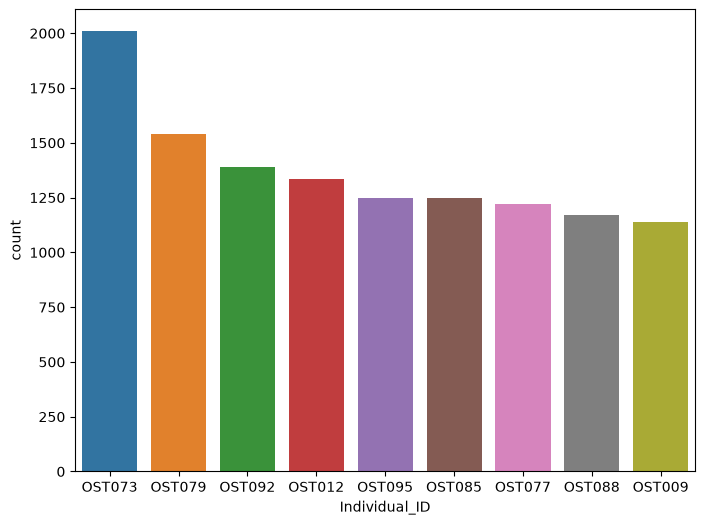

In [5]:
fig, ax = plt.subplots(figsize = (8, 6))
count_by_id = reloc.groupby("Individual_ID").size().rename("count").sort_values(ascending = False).reset_index()
sns.barplot(count_by_id, x = "Individual_ID", y = "count", hue = "Individual_ID")
plt.show()

#### 1.2 Prepare Environmental Layer

##### 1.2.1 Set-Up Remote Sensing Bench

In [5]:
EE_PROJECT = 'test-with-greta'  # change if needed
TARGET_CRS = 'EPSG:32733'
EXPORT_SCALE = 30
BUFFER_M = 0

SHAPES = Path('data/vectors')
PERIMETER_FILE = SHAPES / 'onr_perimeter.shp'
OUT_ZARR = Path('env_32733.zarr')

START = reloc["Timestamp"].min()
END = reloc["Timestamp"].max()

In [6]:
from hsa.remote_sensing import initialize_earth_engine
e = initialize_earth_engine(project=EE_PROJECT)

perimeter_raw = gpd.read_file(PERIMETER_FILE, engine='pyogrio')
perimeter = gpd.GeoDataFrame(
    geometry=[Polygon(perimeter_raw.geometry.iloc[0])],
    crs=perimeter_raw.crs,
).to_crs(TARGET_CRS)

aoi = gpd.GeoDataFrame(geometry=perimeter.geometry.buffer(BUFFER_M), crs=TARGET_CRS)
aoi_wgs84 = aoi.to_crs('EPSG:4326')
aoi_ee = geemap.geopandas_to_ee(aoi_wgs84)

def reset_map():
    Map = geemap.Map()
    Map.addLayer(aoi_ee, {}, "AOI")
    Map.centerObject(aoi_ee, zoom = 10)
    return Map

In [7]:
reloc = reloc[["Individual_ID", "Timestamp", "geometry", "hour"]].copy()

In [8]:
reloc_ee = geemap.gdf_to_ee(reloc[0:1000])

We expect the edge structure to appear as a stark contrast between areas of dense vegetation (high NDVI, strong VV-VH) and areas with a patchy grassland-bare soil matrix (lower NDVI, low VV & VH).

In [9]:
# 1. Sentinel-1 collection
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi_ee.geometry())
    .filterDate(START, END)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
)

# VV - VH difference in dB
# High values: stronger surface/double-bounce signal relative to volume scattering.
# Often highlights bare soil, rock, hard surfaces, sparse vegetation.
vv = s1.select("VV").median().rename("vv_median").clip(aoi_ee)
vh = s1.select("VH").median().rename("vh_median").clip(aoi_ee)
vv_vh_diff = vv.subtract(vh).rename("vv_vh_diff")

# VV/VH ratio in linear space
# High values: bare/rocky/open surfaces.
# Low values: more volume scattering, usually woody or structurally complex vegetation.
vv_lin = ee.Image(10).pow(vv.divide(10)).rename("vv_linear")
vh_lin = ee.Image(10).pow(vh.divide(10)).rename("vh_linear")
vv_vh_ratio = vv_lin.divide(vh_lin).rename("vv_vh_ratio")

Map = reset_map()

# False-colour SAR composite
Map.addLayer(
    ee.Image.cat([vv, vh, vv_vh_diff]),
    {
        "bands": ["vv_median", "vh_median", "vv_vh_diff"],
        "min": [-18, -25, 2],
        "max": [-5, -12, 12],
    },
    "S1 false-colour RGB: VV / VH / VV-VH",
)

# VV/VH ratio
Map.addLayer(
    vv_vh_ratio,
    {
        "min": 1,
        "max": 12,
        "palette": ["08306b", "2171b5", "6baed6", "c6dbef", "ffffcc"],
    },
    "S1 VV/VH ratio: open-rocky vs vegetated",
    False,
)

In [10]:
# ------------------------------------------------------------
# SAR structural edge layer from Sentinel-1 VH
# ------------------------------------------------------------

# Smooth slightly to reduce SAR speckle before edge detection
vh_smooth = vh.focal_mean(
    radius=30,
    units="meters"
)

# Sobel edge detector: highlights abrupt local changes
vh_edge = ee.Algorithms.CannyEdgeDetector(
    image=vh_smooth,
    threshold=1.5,
    sigma=1
).rename("vh_edge")

Map.addLayer(
    vh_edge.selfMask(),
    {"palette": ["red"]},
    "VH structural edges",
    False
)

# Distance to edge
dist_to_vh_edge = (
    vh_edge
    .fastDistanceTransform(256)
    .sqrt()
    .multiply(10)  
    .rename("dist_to_vh_edge_m")
)

# Calculate density of edges
edge_density_50m = vh_edge.unmask(0).focal_mean(radius=50, units="meters").rename("edge_density_50m")
edge_density_100m = vh_edge.unmask(0).focal_mean(radius=100, units="meters").rename("edge_density_100m")
edge_density_250m = vh_edge.unmask(0).focal_mean(radius=250, units="meters").rename("edge_density_250m")

Map.addLayer(dist_to_vh_edge)
Map.addLayer(edge_density_50m)

In [11]:
stack = ee.Image.cat([
    dist_to_vh_edge, 
    edge_density_50m,
    edge_density_100m
])

In [ ]:
from hsa.remote_sensing import ee_image_to_xarray_stack
from hsa.compute import suggest_xy_chunks, persist_if_dask, write_raster_stack_zarr

env = ee_image_to_xarray_stack(
    stack,
    geometry=aoi_ee.geometry(),
    crs="EPSG:32733",
    scale=30,
)

env = env.rio.write_crs("EPSG:32733")
env = env.chunk(suggest_xy_chunks(env, target_chunk_mb=256))
write_raster_stack_zarr(env, "edge_structure_32733.zarr")

### 2. Produce the dataset for estimation

In [32]:
from hsa.compute import open_raster_stack_zarr
env = open_raster_stack_zarr("edge_structure_32733.zarr")

In [38]:
from hsa.sampling import get_availability_domain, sample_available_points, sample_raster_stack
domains = get_availability_domain(reloc, id_col="Individual_ID")
sampling = sample_available_points(domains, used = reloc, n_per_used = 10, id_col = "Individual_ID")
sampled = sample_raster_stack(sampling, env)